# DenseNet121 — Cross-Crop Knowledge Distillation from Lentil Teacher (Phase 3)

**Objective:** Train a DenseNet121 student on the Beans dataset using feature-based knowledge distillation from a ResNet101 teacher model that was trained on the Lentil dataset.

**Teacher:** ResNet101 (trained on Lentil disease classification, 4 classes — frozen during distillation)
**Student:** DenseNet121 (trained on Beans disease classification, 3 classes)

**KD Method:** Feature-based (hint-based) distillation
- Teacher hint layers: `conv4_block23_out` (14x14x1024) and `conv5_block3_out` (7x7x2048)
- Student hint layers: `conv4_block24_concat` (14x14x1024) and `conv5_block16_concat` (7x7x1024)
- Student features are projected via 1x1 Conv2D to match teacher channel dimensions where needed
- Loss: `total_loss = classification_loss + 0.1 * normalized_feature_MSE`

**Scientific Rationale:** Both lentils and beans belong to the Fabaceae family, sharing similar leaf morphology and disease manifestations (e.g., rust). This taxonomical similarity enables meaningful cross-crop knowledge transfer. DenseNet121's dense connectivity pattern promotes feature reuse, making it efficient for learning from teacher features.

**Context:** This is Phase 3 of the project. Results are compared against the baseline (Phase 2, without KD) to quantify the benefit of cross-crop knowledge distillation.

## Imports and Setup

Importing required libraries and dependencies.

In [1]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

## Step 1: Load and Freeze the Teacher Model

Loading the ResNet101 teacher model trained on the Lentil Augmented Dataset. All teacher parameters are frozen — the teacher serves only as a feature extractor during distillation.

In [2]:
teacher = tf.keras.models.load_model(
    r"C:\Users\k nithin\Downloads\M.Tech Project\models\ResNet101_lentil_10.keras",
    compile=False
)

teacher.trainable = False
print("Teacher loaded and frozen")

Teacher loaded and frozen


In [3]:
print("Trainable variables in teacher:",
      len(teacher.trainable_variables))

Trainable variables in teacher: 0


## Step 2: Define Teacher Hint Layers

Selecting intermediate layers from the teacher whose feature representations will be transferred to the student. These layers capture progressively abstract visual features relevant to disease patterns.

In [4]:
TEACHER_HINT_LAYERS = [
    "conv4_block23_out",
    "conv5_block3_out"
]

In [5]:
teacher_feature_extractor = Model(
    inputs=teacher.input,
    outputs=[teacher.get_layer(name).output for name in TEACHER_HINT_LAYERS],
    name="teacher_feature_extractor"
)

teacher_feature_extractor.trainable = False

In [6]:
teacher_feature_extractor.summary()

Model: "teacher_feature_extractor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 42,658,176 (162.73 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 42,658,176 (162.73 MB)

## Step 3: Build and Configure the Student Model

Building the DenseNet121 student model with ImageNet-pretrained weights. Student hint layers (`conv4_block24_concat` at 14x14x1024 and `conv5_block16_concat` at 7x7x1024) are selected to correspond to similar depth/resolution as the teacher hint layers. DenseNet's dense block concatenation results in different channel growth compared to ResNet.

In [7]:
student_base = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

In [8]:
STUDENT_HINT_LAYERS = ["conv4_block24_concat","conv5_block16_concat"]

In [9]:
student_feature_extractor = Model(
    inputs=student_base.input,
    outputs=[student_base.get_layer(name).output for name in STUDENT_HINT_LAYERS],
    name="student_feature_extractor"
)

## Step 4: Feature Projection Layers

Adding 1x1 convolutional projection layers to align the student's feature map channel dimensions with the teacher's. For DenseNet121, the first hint layer matches the teacher (1024 channels), but the second hint layer (1024 channels) needs projection to match the teacher's 2048 channels.

In [10]:
teacher_channels = [
    teacher_feature_extractor.output[i].shape[-1]
    for i in range(2)
]

proj_layers = [
    tf.keras.layers.Conv2D(teacher_channels[0], kernel_size=1, padding="same", name="proj_0"),
    tf.keras.layers.Conv2D(teacher_channels[1], kernel_size=1, padding="same", name="proj_1"),
]

In [11]:
def projection_layer(x, out_channels, name):
    return tf.keras.layers.Conv2D(
        out_channels,
        kernel_size=1,
        padding="same",
        name=name
    )(x)

In [12]:
teacher_channels = [
    teacher_feature_extractor.output[i].shape[-1]
    for i in range(len(teacher_feature_extractor.output))
]

print("Teacher channels:", teacher_channels)

Teacher channels: [1024, 2048]


In [13]:
student_features_raw = student_feature_extractor.output

In [14]:
projected_student_features = []

for i, s_feat in enumerate(student_features_raw):

    student_channels = s_feat.shape[-1]
    teacher_ch = teacher_channels[i]

    if student_channels != teacher_ch:
        s_feat = tf.keras.layers.Conv2D(
            teacher_ch,
            kernel_size=1,
            padding="same",
            name=f"proj_{i}"
        )(s_feat)

    projected_student_features.append(s_feat)

## Imports and Setup

Importing required libraries and dependencies.

In [15]:
import numpy as np

dummy_x = np.random.rand(2, 224, 224, 3).astype("float32")

teacher_feats = teacher_feature_extractor(dummy_x)
student_feats = student_feature_extractor(dummy_x)

for i, (tf, sf) in enumerate(zip(teacher_feats, student_feats)):
    print(f"\nLayer {i}")
    print("Teacher shape:", tf.shape)
    print("Student shape:", sf.shape)


Layer 0
Teacher shape: (2, 14, 14, 1024)
Student shape: (2, 14, 14, 1024)

Layer 1
Teacher shape: (2, 7, 7, 2048)
Student shape: (2, 7, 7, 1024)


## Code

In [16]:
for i, (tf, sf) in enumerate(zip(teacher_feats, student_feats)):
    print(f"\nLayer {i}")
    print("Teacher mean/std:", tf.numpy().mean(), tf.numpy().std())
    print("Student mean/std:", sf.numpy().mean(), sf.numpy().std())


Layer 0
Teacher mean/std: 1.522382 2.2095637
Student mean/std: -0.034033295 0.11327464

Layer 1
Teacher mean/std: 0.09003585 0.69917274
Student mean/std: -0.0058790324 0.056395803


## Step 5: Knowledge Distillation Loss

Defining the feature-based KD loss function:
1. **Per-channel normalization** of both teacher and student feature maps (zero mean, unit variance)
2. **Mean Squared Error (MSE)** between normalized feature maps
3. **Combined loss:** `total = classification_loss + 0.1 * feature_MSE` where lambda = 0.1

In [17]:
def normalize_feature(f):
    mean = tf.reduce_mean(f, axis=[1, 2], keepdims=True)
    std = tf.math.reduce_std(f, axis=[1, 2], keepdims=True) + 1e-6
    return (f - mean) / std

In [18]:
def feature_kd_loss(teacher_feats, student_feats):
    loss = 0.0
    for t_feat, s_feat in zip(teacher_feats, student_feats):
        t_feat = tf.stop_gradient(normalize_feature(t_feat))
        s_feat = normalize_feature(s_feat)
        loss += tf.reduce_mean(tf.square(t_feat - s_feat))
    return loss

## Step 6: Student Classification Head

Adding the final classification layers to the student model with Dropout (0.7) for regularization. The student outputs both class logits (for classification loss) and projected intermediate features (for KD loss).

In [19]:
NUM_CLASSES = 3

## Imports and Setup

Importing required libraries and dependencies.

In [20]:
import tensorflow as tf
x = student_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(4, activation="relu")(x)
x = tf.keras.layers.Dropout(0.8)(x)
student_logits = Dense(NUM_CLASSES, activation=None, name="bean_logits")(x)

## Model Architecture

Building the DenseNet121 model with transfer learning. Using ImageNet pre-trained weights with custom classification head for the disease classes.

In [21]:
student_features_raw = student_feature_extractor.output

student_features_projected = [
    proj_layers[i](student_features_raw[i])
    for i in range(len(student_features_raw))
]

student_model = Model(
    inputs=student_base.input,
    outputs={
        "logits": student_logits,
        "features": student_features_projected
    }
)
student_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 10,190,419 (38.87 MB)

 Trainable params: 10,106,771 (38.55 MB)

 Non-trainable params: 83,648 (326.75 KB)

## Imports and Setup

Importing required libraries and dependencies.

In [22]:
import tensorflow as tf

## Code

In [23]:
classification_loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True
)

In [24]:
KD_WEIGHT = 0.2

In [25]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

## Step 7: Custom Training Step

Implementing a custom training step using `tf.GradientTape` that:
1. Passes input through the frozen teacher to get target feature maps
2. Passes input through the student to get predicted features and class logits
3. Computes both classification loss and feature-matching KD loss
4. Updates only the student's parameters via backpropagation

In [26]:
def train_step(images, labels):
    teacher_feats = teacher_feature_extractor(images)

    with tf.GradientTape() as tape:
        outputs = student_model(images, training=True)
        student_logits = outputs["logits"]
        student_feats = outputs["features"]

        cls_loss = classification_loss_fn(labels, student_logits)
        kd_loss = feature_kd_loss(teacher_feats, student_feats)

        total_loss = cls_loss + KD_WEIGHT * kd_loss

    grads = tape.gradient(total_loss, student_model.trainable_variables)
    optimizer.apply_gradients(zip(grads, student_model.trainable_variables))

    return {
        "total_loss": total_loss,
        "cls_loss": cls_loss,
        "kd_loss": kd_loss
    }

In [27]:
dummy_y = tf.constant([0, 1])

losses = train_step(dummy_x, dummy_y)
print(losses)

{'total_loss': <tf.Tensor: shape=(), dtype=float32, numpy=1.7505719661712646>, 'cls_loss': <tf.Tensor: shape=(), dtype=float32, numpy=1.0986123085021973>, 'kd_loss': <tf.Tensor: shape=(), dtype=float32, numpy=3.259798526763916>}


## Step 8: Load Beans Dataset

Loading the Beans Leaf Disease Dataset (3 classes: Anthracnose, Healthy, Rust) with train/validation/test splits.

In [28]:
import tensorflow as tf
import pathlib

DATA_DIR = pathlib.Path(r"C:\Users\k nithin\Downloads\M.Tech Project\Beans dataset")
IMG_SIZE = (224,224)
BATCH_SIZE = 8
SEED = 42
NUM_CLASSES = 3

## Data Loading and Preprocessing

Loading the dataset and applying preprocessing (normalization, augmentation, etc.).

In [29]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=0.3,
    subset="training"
)

Found 59069 files belonging to 3 classes.
Using 41349 files for training.


In [30]:
val_test_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=0.3,
    subset="validation"
)

Found 59069 files belonging to 3 classes.
Using 17720 files for validation.


## Code

In [31]:
val_batches = tf.data.experimental.cardinality(val_test_ds).numpy()
test_ds = val_test_ds.take(val_batches // 2)
val_ds = val_test_ds.skip(val_batches // 2)

In [32]:
class_names = train_ds.class_names
print("Class order:", class_names)

Class order: ['anthra', 'healthy', 'rust']


In [33]:
train_batches = tf.data.experimental.cardinality(train_ds).numpy()
print("Train batches per epoch:", train_batches)
print("Approx images per epoch:", train_batches * BATCH_SIZE)

Train batches per epoch: 5169
Approx images per epoch: 41352


## Imports and Setup

Importing required libraries and dependencies.

In [34]:
from tensorflow.keras.applications.resnet import preprocess_input

def preprocess(image, label):
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image, label

## Code

In [35]:
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

In [36]:
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

## Imports and Setup

Importing required libraries and dependencies.

In [37]:
import time

images, labels = next(iter(train_ds))

start = time.time()
losses = train_step(images, labels)
end = time.time()

print("One train_step time (seconds):", end - start)
print(losses)

One train_step time (seconds): 7.527478456497192
{'total_loss': <tf.Tensor: shape=(), dtype=float32, numpy=2.5955376625061035>, 'cls_loss': <tf.Tensor: shape=(), dtype=float32, numpy=1.907468318939209>, 'kd_loss': <tf.Tensor: shape=(), dtype=float32, numpy=3.440347194671631>}


## Step 9: Training Loop

Training the student model with the combined classification + KD loss. The teacher remains frozen throughout — only student weights are updated.

In [38]:
STEPS_PER_EPOCH = 40
EPOCHS = 10

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    step = 0
    for images, labels in train_ds:
        losses = train_step(images, labels)
        step += 1

        if step >= STEPS_PER_EPOCH:
            break

    print(
        f"Train | total: {losses['total_loss']:.4f} | "
        f"cls: {losses['cls_loss']:.4f} | "
        f"kd: {losses['kd_loss']:.4f}"
    )

    val_cls_loss = tf.keras.metrics.Mean()
    val_acc = tf.keras.metrics.SparseCategoricalAccuracy()

    for images, labels in val_ds:
        outputs = student_model(images, training=False)
        logits = outputs["logits"]

        loss = classification_loss_fn(labels, logits)
        val_cls_loss.update_state(loss)
        val_acc.update_state(labels, logits)

    print(
        f"Val   | cls_loss: {val_cls_loss.result():.4f} | "
        f"acc: {val_acc.result():.4f}"
    )


Epoch 1/10
Train | total: 2.1098 | cls: 1.4410 | kd: 3.3439
Val   | cls_loss: 0.8709 | acc: 0.5422

Epoch 2/10
Train | total: 1.4545 | cls: 0.8270 | kd: 3.1375
Val   | cls_loss: 0.6738 | acc: 0.6067

Epoch 3/10
Train | total: 1.4265 | cls: 0.8466 | kd: 2.8997
Val   | cls_loss: 0.6109 | acc: 0.7206

Epoch 4/10
Train | total: 1.6605 | cls: 1.0983 | kd: 2.8110
Val   | cls_loss: 0.6115 | acc: 0.7750

Epoch 5/10
Train | total: 1.6491 | cls: 1.0966 | kd: 2.7628
Val   | cls_loss: 0.6077 | acc: 0.9227

Epoch 6/10
Train | total: 1.6483 | cls: 1.0926 | kd: 2.7783
Val   | cls_loss: 0.6993 | acc: 0.8862

Epoch 7/10
Train | total: 1.6248 | cls: 1.0957 | kd: 2.6455
Val   | cls_loss: 0.5905 | acc: 0.7801

Epoch 8/10
Train | total: 1.4182 | cls: 0.8904 | kd: 2.6388
Val   | cls_loss: 0.6241 | acc: 0.8725

Epoch 9/10
Train | total: 1.6092 | cls: 1.0914 | kd: 2.5889
Val   | cls_loss: 0.6119 | acc: 0.9332

Epoch 10/10
Train | total: 1.5701 | cls: 1.0867 | kd: 2.4170
Val   | cls_loss: 0.6065 | acc: 0.9387

In [40]:
SAVE_DIR = r"C:\Users\k nithin\Downloads\M.Tech Project\models"

## Knowledge Distillation

Transferring knowledge from a larger teacher model to a smaller student model for improved performance.

In [41]:
import os 
student_model.save(os.path.join(SAVE_DIR, "densenet121_beans_distilled.keras"))
reloaded = tf.keras.models.load_model(os.path.join(SAVE_DIR, "densenet121_beans_distilled.keras"), compile=False)

reload_acc = tf.keras.metrics.SparseCategoricalAccuracy()
for images, labels in val_ds:
    outputs = reloaded(images, training=False)
    logits = outputs["logits"]
    reload_acc.update_state(labels, logits)

print(f"Reloaded model validation accuracy: {reload_acc.result():.4f}")

Reloaded model validation accuracy: 0.9389


## Step 10: Evaluation

Computing test accuracy, confusion matrix, classification report, and ROC curves to evaluate the distilled student model's performance.

In [42]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:
    outputs = student_model(images, training=False)
    logits = outputs["logits"]

    probs = tf.nn.softmax(logits)

    y_prob.extend(probs.numpy())
    y_pred.extend(np.argmax(probs.numpy(), axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

## Imports and Setup

Importing required libraries and dependencies.

In [43]:
from sklearn.metrics import accuracy_score

test_acc = accuracy_score(y_true, y_pred)
print("Test Accuracy:", test_acc)

Test Accuracy: 0.9366531165311653


## Performance Metrics

Visualizing training curves and computing detailed metrics (confusion matrix, precision, recall, F1-score).

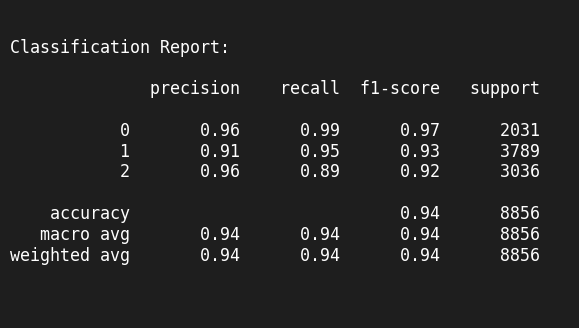

In [46]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

report_text = "Classification Report:\n\n" + classification_report(y_true, y_pred)

fig = plt.figure(figsize=(7, 4))
fig.patch.set_facecolor('#1e1e1e')

plt.text(0.1, 0.5, report_text, 
         color='white', 
         fontsize=12, 
         family='monospace', 
         transform=fig.transFigure, 
         verticalalignment='center')

plt.axis('off')

plt.savefig('terminal_classification_report.png', facecolor=fig.get_facecolor(), bbox_inches='tight', dpi=300)
plt.show()

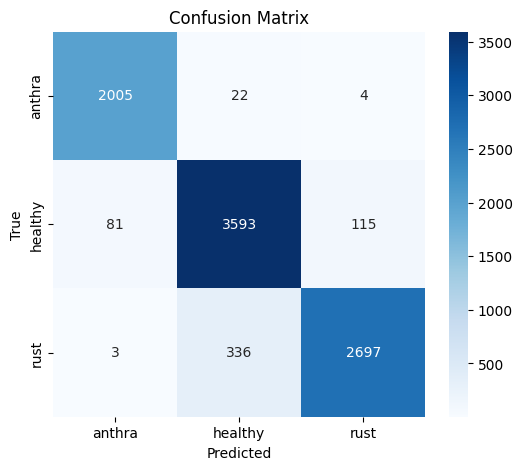

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

## ROC Curves

Plotting per-class ROC curves with AUC scores for the distilled student model on the Beans test set.

In [48]:
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

n_classes = len(class_names)

y_true_bin = label_binarize(y_true, classes=range(n_classes))

## Code

In [49]:
roc_auc = roc_auc_score(y_true_bin, y_prob, multi_class='ovr')
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9627382804752345


## Performance Metrics

Visualizing training curves and computing detailed metrics (confusion matrix, precision, recall, F1-score).

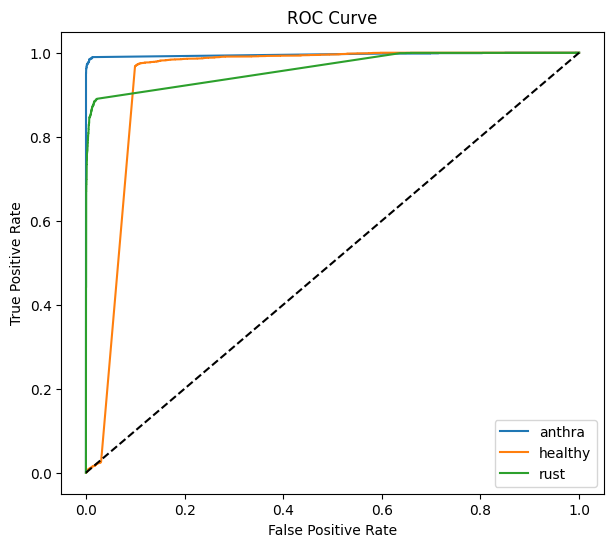

In [50]:
plt.figure(figsize=(7,6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, label=f"{class_names[i]}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Code